<a href="https://colab.research.google.com/github/defz-07/pengolahan-data-skripsi/blob/main/Analisis_Data_Kualitatif_Harapan_Perawat_terkait_Perbaikan_Sistem_dan_Pengalaman_Pengguna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
import pandas as pd
import numpy as np
import re
import string

In [5]:
# Load dataset
df = pd.read_excel('Data Kualitatif Mengenai Harapan.xlsx')

df

,"Apakah Anda mengharapkan perbaikan untuk aspek pengalaman pengguna EHR di Instalasi Rawat Inap RSA UGM pada masa mendatang? Jika iya, mohon jelaskan harapan dan saran Anda"
0,"Iya, saya berharap terus melakukan inovasi per..."
1,"Iya, harapan yg jelas aksesnya mudah tidak lol..."
2,"Ya, supaya bisa meringkas otomatis saat discar..."
3,sudah cukup
4,bagian jaringannya saja mungkin perlu di tingk...
5,Bisa ditingkatkan terus demi kebaikan bersama
6,untuk lembar monitoring ttv bisa ditambahkan c...
7,Semoga kedepannya lebih baik dan memudahkan pa...
8,Tidak sudah bagus
9,Bisa


In [6]:
# Melihat semua nama kolom
print(df.columns)

data = df[['Apakah Anda mengharapkan perbaikan untuk aspek pengalaman pengguna EHR di Instalasi Rawat Inap RSA UGM pada masa mendatang? Jika iya, mohon jelaskan harapan dan saran Anda']]

# Rename kolom agar lebih mudah
data.columns = ['response']

# Tampilkan data
data.head()

# Jumlah data
print("Jumlah data:", len(data))

# Cek missing value
print(data.isnull().sum())

# Hapus data kosong
data = data.dropna()

# Reset index
data = data.reset_index(drop=True)

print("Jumlah data setelah cleaning:", len(data))

# Menampilkan beberapa contoh jawaban
for i in range(5):
    print(f"Data {i+1}:")
    print(data['response'][i])
    print()

Index(['Apakah Anda mengharapkan perbaikan untuk aspek pengalaman pengguna EHR di Instalasi Rawat Inap RSA UGM pada masa mendatang? Jika iya, mohon jelaskan harapan dan saran Anda'], dtype='object')
Jumlah data: 33
response    0
dtype: int64
Jumlah data setelah cleaning: 33
Data 1:
Iya, saya berharap terus melakukan inovasi perbaikan kedepannya agar lebih mudah dan mendukung dalam asuhan keperawatan yang menyeluruh

Data 2:
Iya, harapan yg jelas aksesnya mudah tidak lola aksesnya

Data 3:
Ya, supaya bisa meringkas otomatis saat discard planning mau diprint supaya tidak mengisi ulang

Data 4:
sudah cukup

Data 5:
bagian jaringannya saja mungkin perlu di tingktkan, terkadang sangat lama loadinya jika di pakai



# Preprocessing

In [9]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [24]:
stop_words = stopwords.words('indonesian')

important_words = [
    'ada',
    'perlu',
    'ditambahkan',

    # Pertahankan kata negasi
    'tidak',
    'kurang',
    'belum',

    # Sentiment positif
    'baik',
    'bisa',
    'bagus',
    'mudah',
    'cepat',
    'lengkap',
    'jelas',
    'nyaman',

    'lebih',
    'cukup',

    # Sentiment negatif
    'lama',
    'lambat',
    'sulit',
    'error',
    'gangguan',
    'bingung',
    'rumit',

    # Domain UX
    'perawat',
    'pasien',
]

# NORMALIZATION DICTIONARY

normalization_dict = {
    # Negasi
    'gak': 'tidak',
    'ga': 'tidak',
    'nggak': 'tidak',
    'tdk': 'tidak',

    # Kata umum
    'jg': 'juga',
    'tp': 'tetapi',
    'yg': 'yang',
    'udh': 'sudah',
    'sdh': 'sudah',
    'bgt': 'banget',
    'krn': 'karena',
    'dr': 'dari',
    'dgn': 'dengan',
    'trs': 'terus',

    # Domain UX / kesehatan
    'lola': 'lama',
    'simrs': 'ehr',
    'rm': 'rekam medis',

    # Typo
    'gk': 'tidak',
    'sm': 'sama',
    'udah': 'sudah',
    'memudahan': 'memudahkan',
    'tingktkan': 'tingkatkan',
    'loadinya': 'loadingnya',
    'penggunakan': 'penggunaan',
    'tehnologi': 'teknologi',
    'dimasukan': 'dimasukkan',
    'teruploas': 'terupload',
    'tampilannya': 'tampilan',

    'terkadang': 'kadang',
    'harapannya': 'harapan',
    'on point': 'tepat',
    'point': 'tepat',
}

additional_stopwords = [
    # Sentimen umum
    'lebih',
    'bisa',

    # Kata umum
    'iya',
    'iyaa',
    'semoga',
    'harap',
    'harapannya',
    'mungkin',
    'untuk',
    'saat',
    'dimasa',
]

# REMOVE IMPORTANT WORDS DARI STOPWORDS
stop_words = [
    word for word in stop_words
    if word not in important_words
]

# Tambahkan additional stopwords
stop_words.extend(additional_stopwords)

# FUNCTION PREPROCESSING
def preprocess_text(text):

    # 1. Pastikan string
    text = str(text)

    # 2. Lowercase
    text = text.lower()

    # 3. Remove angka
    text = re.sub(r'\d+', '', text)

    # 4. Remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # 5. Remove whitespace
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)

    # 6. Tokenization
    tokens = word_tokenize(text)

    # 7. Normalization
    normalized_tokens = []

    for word in tokens:
        if word in normalization_dict:
            normalized_tokens.append(
                normalization_dict[word]
            )
        else:
            normalized_tokens.append(word)

    # 8. Stopword removal
    filtered_tokens = []

    for word in normalized_tokens:
        # Pertahankan kata penting
        if word not in stop_words:
            # Hapus token sangat pendek
            if len(word) > 2:
                filtered_tokens.append(word)

    # 9. Gabungkan kembali
    final_text = ' '.join(filtered_tokens)

    return final_text

In [25]:
import nltk
nltk.download('punkt_tab')
# =========================
# APPLY PREPROCESSING
# =========================

data['clean_text'] = data['response'].apply(preprocess_text)

# =========================
# HASIL PREPROCESSING
# =========================

data[['response', 'clean_text']].head(33)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,response,clean_text
0,"Iya, saya berharap terus melakukan inovasi per...",berharap inovasi perbaikan kedepannya mudah me...
1,"Iya, harapan yg jelas aksesnya mudah tidak lol...",harapan jelas aksesnya mudah tidak lama aksesnya
2,"Ya, supaya bisa meringkas otomatis saat discar...",meringkas otomatis discard planning diprint ti...
3,sudah cukup,cukup
4,bagian jaringannya saja mungkin perlu di tingk...,jaringannya perlu tingkatkan kadang lama loadi...
5,Bisa ditingkatkan terus demi kebaikan bersama,ditingkatkan kebaikan
6,untuk lembar monitoring ttv bisa ditambahkan c...,lembar monitoring ttv ditambahkan catatan menu...
7,Semoga kedepannya lebih baik dan memudahkan pa...,kedepannya baik memudahkan nakes melayani pasien
8,Tidak sudah bagus,tidak bagus
9,Bisa,


In [26]:
# CEK DATA KOSONG
empty_data = data[
    data['clean_text'].str.strip() == ''
]

print(empty_data)

   response clean_text  word_count
9      Bisa                      1
24     Bisa                      1


In [27]:
data.to_excel('hasil_preprocessing.xlsx', index=False)

# NLP Techniques

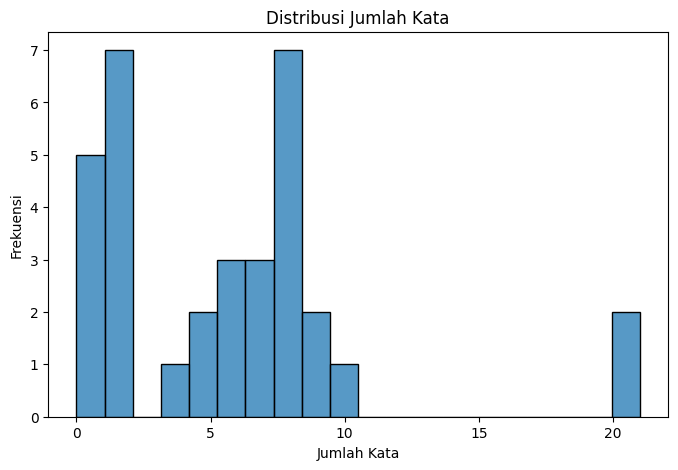

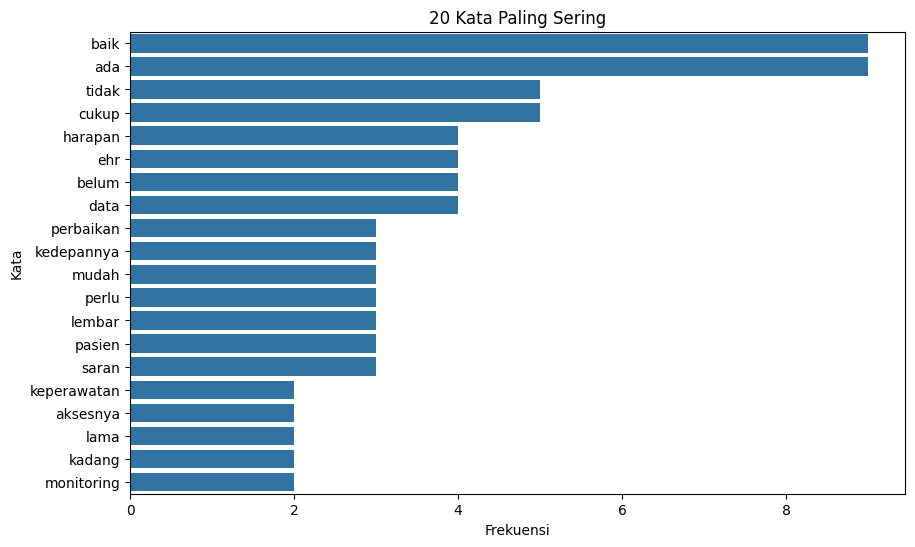

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Jumlah kata
data['word_count'] = data['clean_text'].apply(lambda x: len(x.split()))

# Statistik jumlah kata
data['word_count'].describe()

# DISTRIBUSI PANJANG TEKS
plt.figure(figsize=(8,5))
sns.histplot(data['word_count'], bins=20)
plt.title('Distribusi Jumlah Kata')
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi')

plt.show()

# Gabungkan semua teks
all_text = ' '.join(data['clean_text'])

# Frekuensi kata
from collections import Counter

words = all_text.split()
word_freq = Counter(words)

# 20 kata paling sering
top_words = word_freq.most_common(20)
top_words
top_words_df = pd.DataFrame(top_words, columns=['word', 'frequency'])

# Visualisasi top words
plt.figure(figsize=(10,6))
sns.barplot(
    data=top_words_df,
    x='frequency',
    y='word'
)

plt.title('20 Kata Paling Sering')
plt.xlabel('Frekuensi')
plt.ylabel('Kata')

plt.show()

In [29]:
top_words_df[['word', 'frequency']].head(15)

,word,frequency
0,baik,9
1,ada,9
2,tidak,5
3,cukup,5
4,harapan,4
5,ehr,4
6,belum,4
7,data,4
8,perbaikan,3
9,kedepannya,3


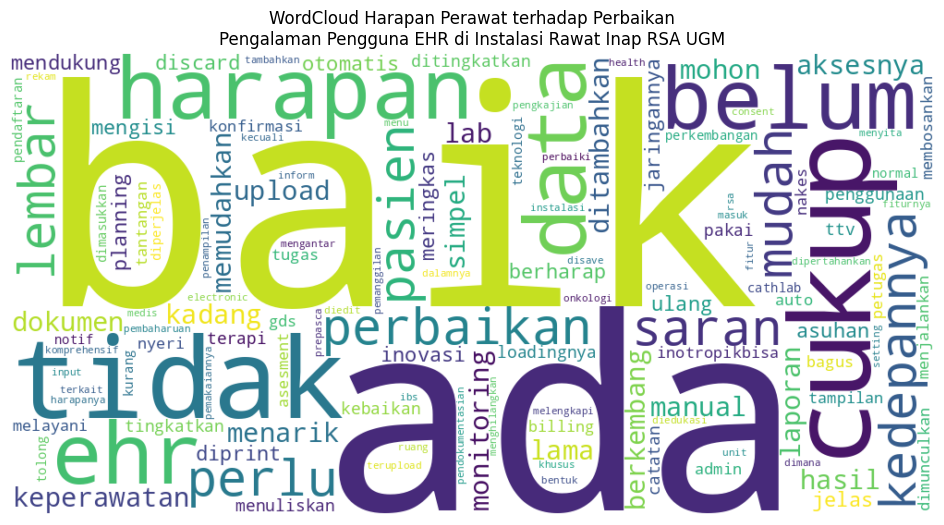

In [32]:
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(all_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')

plt.title('WordCloud Harapan Perawat terhadap Perbaikan\n'
    'Pengalaman Pengguna EHR di Instalasi Rawat Inap RSA UGM')

plt.show()

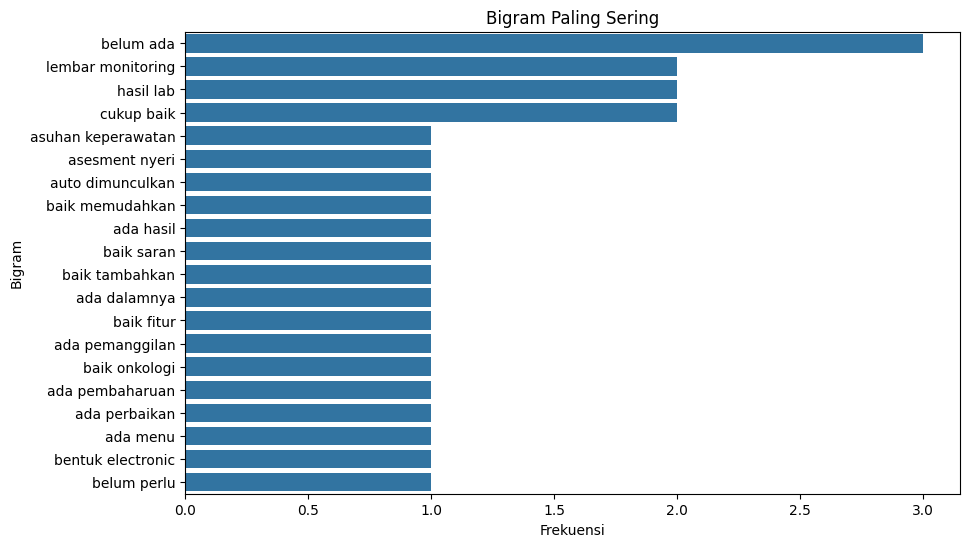

,bigram,frequency
0,belum ada,3
1,lembar monitoring,2
2,hasil lab,2
3,cukup baik,2
4,asuhan keperawatan,1
5,asesment nyeri,1
6,auto dimunculkan,1
7,baik memudahkan,1
8,ada hasil,1
9,baik saran,1


In [35]:
from sklearn.feature_extraction.text import CountVectorizer

# Bigram
bigram_vectorizer = CountVectorizer(
    ngram_range=(2,2),
    max_features=20
)

X_bigram = bigram_vectorizer.fit_transform(data['clean_text'])

bigram_counts = X_bigram.sum(axis=0)

bigram_freq = [
    (word, bigram_counts[0, idx])
    for word, idx in bigram_vectorizer.vocabulary_.items()
]

bigram_freq = sorted(
    bigram_freq,
    key=lambda x: x[1],
    reverse=True
)

bigram_freq

# Visualisasi bigram
bigram_df = pd.DataFrame(
    bigram_freq,
    columns=['bigram', 'frequency']
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=bigram_df,
    x='frequency',
    y='bigram'
)

plt.title('Bigram Paling Sering')
plt.xlabel('Frekuensi')
plt.ylabel('Bigram')

plt.show()

bigram_df[['bigram', 'frequency']]

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    # Jumlah maksimal feature
    max_features=1000,

    # Gunakan unigram + bigram
    ngram_range=(1,2),

    # Minimal muncul di 1 dokumen
    min_df=1,

    # Maksimal muncul di 90% dokumen
    max_df=0.9
)

# TF-IDF transformation
X = tfidf.fit_transform(
    data['clean_text']
)

# Matrix shape
print(X.shape)

# Feature names
feature_names = tfidf.get_feature_names_out()

print(feature_names)

(33, 287)
['ada' 'ada dalamnya' 'ada hasil' 'ada menu' 'ada notif' 'ada pemanggilan'
 'ada pembaharuan' 'ada perbaikan' 'admin' 'aksesnya' 'aksesnya mudah'
 'asesment' 'asesment nyeri' 'asuhan' 'asuhan keperawatan' 'auto'
 'auto dimunculkan' 'bagus' 'baik' 'baik fitur' 'baik memudahkan'
 'baik onkologi' 'baik saran' 'baik tambahkan' 'belum' 'belum ada'
 'belum perlu' 'bentuk' 'bentuk electronic' 'berharap' 'berharap inovasi'
 'berkembang' 'berkembang memudahkan' 'billing' 'billing auto' 'catatan'
 'catatan menuliskan' 'cathlab' 'cathlab mohon' 'consent' 'consent bentuk'
 'cukup' 'cukup baik' 'cukup tolong' 'dalamnya' 'data' 'data data'
 'data input' 'data laporan' 'data terkait' 'diedit' 'diedit data'
 'diedukasi' 'diedukasi unit' 'dimana' 'dimana kadang' 'dimasukkan'
 'dimasukkan ehr' 'dimunculkan' 'dimunculkan konfirmasi' 'diperjelas'
 'diperjelas mudah' 'dipertahankan' 'dipertahankan baik' 'diprint'
 'diprint tidak' 'disave' 'disave tidak' 'discard' 'discard planning'
 'ditambahkan'

In [38]:
tfidf_df = pd.DataFrame(
    X.toarray(),
    columns=feature_names
)

tfidf_df.head()

,ada,ada dalamnya,ada hasil,ada menu,ada notif,ada pemanggilan,ada pembaharuan,ada perbaikan,admin,aksesnya,...,ttv,ttv ditambahkan,tugas,tugas tantangan,ulang,unit,unit pemakaiannya,upload,upload dokumen,upload menghilangkan
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.543152,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.262532,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0


In [39]:
# TF-IDF mean
mean_tfidf = tfidf_df.mean().sort_values(
    ascending=False
)

print(mean_tfidf.head(33))

cukup                    0.100429
baik                     0.093935
ada                      0.069805
belum                    0.050751
belum ada                0.045582
cukup baik               0.042253
tidak                    0.035542
harapan                  0.026241
ehr                      0.024951
kedepannya               0.024811
data                     0.023543
perlu                    0.022602
perbaikan                0.021982
mudah                    0.019884
penampilan               0.019824
penampilan baik          0.019824
tidak bagus              0.019131
bagus                    0.019131
pasien                   0.018847
menarik                  0.018587
simpel                   0.018587
saran                    0.018459
kebaikan                 0.017495
ditingkatkan             0.017495
ditingkatkan kebaikan    0.017495
lab                      0.016619
hasil                    0.016619
hasil lab                0.016619
aksesnya                 0.016459
mohon         

Distribusi Jumlah Perawat yang Mengharapkan Perbaikan dan Tidak Mengharapkan Perbaikan

Jumlah data : 33
Nama kolom  : ['Apakah Anda mengharapkan perbaikan untuk aspek pengalaman pengguna EHR di Instalasi Rawat Inap RSA UGM pada masa mendatang? Jika iya, mohon jelaskan harapan dan saran Anda']

Jumlah respons valid : 33

Tabel Distribusi Jawaban
                       Kategori  Frekuensi  Persentase (%)
0        Mengharapkan Perbaikan         24            72.7
1  Tidak Mengharapkan Perbaikan          9            27.3


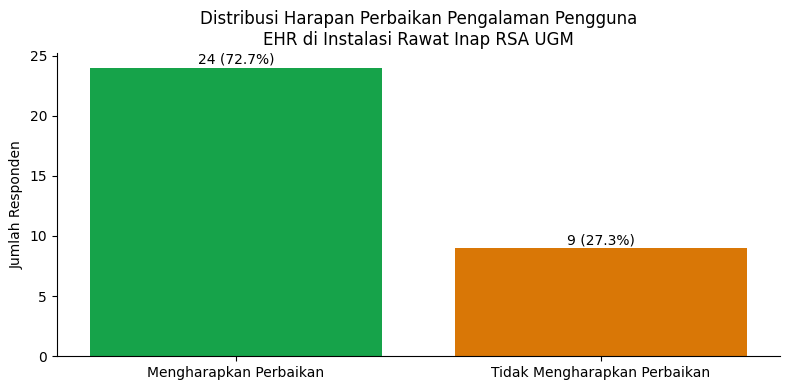

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# WARNA VISUALISASI
COLOR_YES = '#16A34A'   # Hijau
COLOR_NO  = '#D97706'   # Orange

# Membaca file Excel
df_raw = pd.read_excel('Data Kualitatif Mengenai Harapan.xlsx')

# Menampilkan informasi dataset
print("Jumlah data :", len(df_raw))
print("Nama kolom  :", df_raw.columns.tolist())

# Menggunakan kolom pertama sebagai jawaban responden
response_column = df_raw.columns[0]

# Membuat dataframe baru
df = pd.DataFrame()

# Membersihkan data
df['response'] = (
    df_raw[response_column]
    .astype(str)
    .str.strip()
)

# Menghapus jawaban kosong
df = df[df['response'].str.len() > 1]

# Reset index
df = df.reset_index(drop=True)

print("\nJumlah respons valid :", len(df))

# Mengubah singkatan menjadi kata lengkap
normalization_dict = {
    r'\byg\b'   : 'yang',
    r'\butk\b'  : 'untuk',
    r'\bdgn\b'  : 'dengan',
    r'\btdk\b'  : 'tidak',
    r'\bkrn\b'  : 'karena',
    r'\bblm\b'  : 'belum',
    r'\bsdh\b'  : 'sudah',
    r'\bdr\b'   : 'dari',
}

def normalize_text(text):

    text = text.lower()

    for pattern, replacement in normalization_dict.items():
        text = re.sub(pattern, replacement, text)

    return text

# Kata kunci yang menunjukkan TIDAK mengharapkan perbaikan
no_patterns = [
    'sudah cukup',
    'cukup baik',
    'sudah baik',
    'sudah bagus',
    'belum perlu',
    'tidak ada kendala',
    'sejauh ini belum',
]

# Kata kunci yang menunjukkan MENGHARAPKAN perbaikan
yes_patterns = [
    r'\biya\b',
    r'\bya\b',
    r'\bharap\b',
    r'\bsaran\b',
    r'\bperbaikan\b',
    r'\bdiperbaiki\b',
    r'\bditingkatkan\b',
    r'\bditambahkan\b',
    r'\bsemoga\b',
]

# Fungsi kategorisasi
def categorize_response(text):

    text = normalize_text(text)

    # Cek kategori tidak mengharapkan perbaikan
    for pattern in no_patterns:
        if pattern in text:
            return 'Tidak Mengharapkan Perbaikan'

    # Cek kategori mengharapkan perbaikan
    for pattern in yes_patterns:
        if re.search(pattern, text):
            return 'Mengharapkan Perbaikan'

    # Jika tidak masuk keduanya,
    # otomatis dianggap mengharapkan perbaikan
    return 'Mengharapkan Perbaikan'

# Menerapkan kategorisasi
df['category'] = df['response'].apply(categorize_response)

# Menghitung frekuensi
frequency_table = df['category'].value_counts().reset_index()

# Mengubah nama kolom
frequency_table.columns = ['Kategori', 'Frekuensi']

# Menghitung persentase
frequency_table['Persentase (%)'] = (
    frequency_table['Frekuensi'] / len(df) * 100
).round(1)

# Menampilkan tabel
print("\nTabel Distribusi Jawaban")
print(frequency_table)

# Menentukan warna diagram
colors = [
    COLOR_YES if category == 'Mengharapkan Perbaikan'
    else COLOR_NO
    for category in frequency_table['Kategori']
]

# Membuat figure
plt.figure(figsize=(8, 4))

# Membuat bar chart
bars = plt.bar(
    frequency_table['Kategori'],
    frequency_table['Frekuensi'],
    color=colors
)

# Menambahkan label jumlah dan persentase
for i, bar in enumerate(bars):

    freq = frequency_table['Frekuensi'][i]
    pct  = frequency_table['Persentase (%)'][i]

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f'{freq} ({pct}%)',
        ha='center',
        fontsize=10
    )

# Judul dan label
plt.title(
    'Distribusi Harapan Perbaikan Pengalaman Pengguna\n'
    'EHR di Instalasi Rawat Inap RSA UGM'
)

plt.ylabel('Jumlah Responden')

# Menghapus garis atas dan kanan
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Menampilkan visualisasi
plt.tight_layout()

plt.show()